# Caratteristica voltamperometrica e misura spettroscopica dell’emissione di LED

A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

## Introduzione

Esponendo un semiconduttore alla radiazione elettromagnetica, se l’energia del singolo fotone $E = hν = hc/ \lambda$ è maggiore del gap $E_g$ del semiconduttore,  è possibile che il fotone venga assorbito dando origine ad una coppia elettrone-lacuna. Questo significa un elettrone in più in banda di conduzione ed una lacuna in più in banda di valenza. Si ha quindi una variazione nel numero di portatori (sia elettroni che lacune, simultaneamente) che partecipano sia ai moti diffusivi che di deriva (in presenza di un campo elettrico).

La risposta di un diodo illuminato (o fotodiodo) è descritta dalla legge:

$$I = I_0 (e^{\frac{qV}{kT}}- 1)-I_{ph}$$

Dove:  
- $q=1.602 \cdot 10^{-19}C$ è la carica dell'elettrone,
- $k = 1.380 \cdot 10^{-23} J/K$ è la costante di bolzmann,
- $T$ è temperatura in kelvin dell'ambiente di lavoro,
- $V$ è il potenziale ai capi del diodo,
- $I$ è la corrente nel diodo,
- $I_0$ è la corrente di saturazione del diodo,
- $I_{ph}$ è la corrente prodotta dall'esposizione della radiazione elettromagnetica.

Risulta $I_{ph}$ proporzionale al numero di fotoni assorbiti, provenienti in questo caso dal LED accoppiato.

Il diodo in polarizzazione diretta induce una forte iniezione di portatori di minoranza, fuori equilibrio, forzando in tal modo il processo di ricombinazione. In tale processo si possono distinguere diversi contributi che vengono distinti tra processi di ricombinazione radiativi (con emissione di fotoni), e processi non radiativi. Privilegiando il primo, si ottiene emissione di luce con intensità proporzionale alla corrente che fluisce nel diodo.

Nel fotodiodo, i portatori iniettati (vale a dire gli elettroni) si ricombinano con le buche presenti, liberando un energia pari al gap del semiconduttore $E_g$; in particolare, se la ricombinazione è radiativa, viene emesso un fotone di energia:

$$E_g = hν = hc/\lambda$$

Sottoponendo la radiazione emessa da un LED a un reticolo di diffrazione, dotato di passo d (vale a dire 1/d righe per unità di lunghezza), essa diffrange secondo la relazione di Bragg:

$$d \sin \vartheta = n \lambda$$

Valida con buona approssimazione per onde elettromagnetiche piane. Limitandosi al primo ordine e conoscendo d, è possibile stabilire una relazione tra l’angolo di diffrazione e la lunghezza d’onda.

## Scopo dell'esperimento

Scopo dell'esperimento è quello di caratterizzare elettricamente e otticamente l'emissione di una serie di LED, ciascuno di un valore differente, alla luce delle leggi annotate nell'introduzione a questa relazione.

## Strumentazione

Si hanno a disposizione 4 LED di colore differente e 1 fotodiodo in silicio; per l'alimentazione dei LED, si utilizza un alimentatore in continua.

Per la realizzazione della prima parte della prova, si utilizzano, inoltre:

+ due multimetri, da utilizzare per le misurazioni voltamperometriche;
+ cavi e connettori coassiali;
+ Una resistenza da 500 $\Omega$.

In più, per la caratterizzazione ottica occorrono anche:

+ un binario, su cui fissare ciascun LED;
+ un braccio rotante, su cui fissare il fotodiodo;
+ tre supporti per le ottiche ausiliarie (vale a dire due lenti);
+ un foglio, dotato di scala goniometrica.

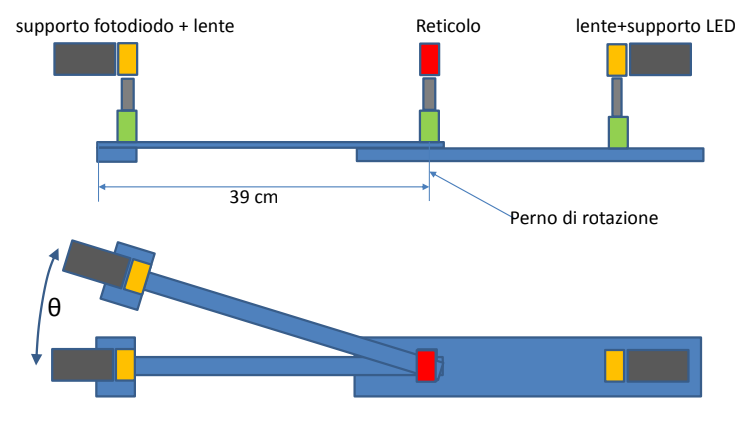

## Procedura sperimentale

### Caratterizzazione elettrica

Alimentando progressivamente il LED, si registrano le coppie di valori tensione-corrente, avendo l'accortezza di non superare la soglia di 20 mA di corrente, per evitare danni alla strumentazione.

Inoltre, si osserva il comportamento del dispositivo polarizzato in diretta e in inversa, prendendo nota dei valori corrispondenti al primo apparire dell’emissione luminosa (nei LED).

Con i dati ottenuti si può verificare dunque la legge esponenziale vista nell'introduzione, ricavando il valore $I_0$.

### Caratterizzazione ottica

Una volta montata la strumentazione come mostrato nella sezione precedente, si può alimentare il LED come visto per la caratterizzazione elettrica del LED.

A questo punto, dalla lettura del valore di tensione in uscita al fotodiodo ad angolo variabile, si ricava la lunghezza d’onda della luce emessa dai diversi LED.

## Importazione e analisi dei dati sperimentali

Di seguito sono riportati gli snippets utilizzati per l'analisi dei dati.

Su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/04_LED_ELECTRIC_OPTIC) è possibile visualizzare i dati raccolti in formato tabulato.

### Caratterizzazione elettrica

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
from scipy import constants as scc
import matplotlib.pyplot as plt  
import pandas as pd

# Importa i dati

filename = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/04_LED_ELECTRIC_OPTIC/LED_ELECTRIC_SPECTRUM.CSV'

data = pd.read_csv(filename)

# Converto i dati in numpy arrays, usando unità S.I.

corrente=data['Diode Current (mA)'].to_numpy()  # Su GitHub questi dati sono in A, anche se sono stati contrassegnati come mA
rosso=data['Red Voltage (V)'].to_numpy()
giallo=data['Yellow Voltage (V)'].to_numpy()
verde=data['Green Voltage (V)'].to_numpy()
blu=data['Blue Voltage (V)'].to_numpy()
fotodiodo=data['PD Voltage (V)'].to_numpy()
bianco=data['White Voltage (V)'].to_numpy()

print('Importazione dei dati completata.')

Importazione dei dati completata.


In [ ]:
# Definisci costanti fisiche utili

electron_charge = scc.e
Boltzmann = scc.Boltzmann
temperature = 300

# Fit dei dati

def rossof(rosso,I0,n):
    corrente=I0*(np.exp(electron_charge*rosso/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-100, 10
n_min, n_max = 0.5, 30
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(rossof, rosso, corrente, bounds=bounds)
I0_fit_rosso = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_rosso  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_rosso = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED rosso:       (', np.format_float_scientific(I0_fit_rosso,precision=2), '±', np.format_float_scientific(sigma_rosso[0],precision=1), ') A')
print('Parametro di idealità per LED rosso:                 (', np.format_float_scientific(n_fit_rosso,precision=2),  '±', np.format_float_scientific(sigma_rosso[1],precision=0), ' ) ')

def giallof(giallo,I0,n):
    corrente=I0*(np.exp(electron_charge*giallo/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-10, 10
n_min, n_max = 0.5, 300
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(giallof, giallo, corrente, bounds=bounds)
I0_fit_giallo = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_giallo  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_giallo = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED giallo:      (', np.format_float_scientific(I0_fit_giallo,precision=2), '±', np.format_float_scientific(sigma_giallo[0],precision=1), ') A')
print('Parametro di idealità per LED giallo:                (', np.format_float_scientific(n_fit_giallo,precision=2),  '±', np.format_float_scientific(sigma_giallo[1],precision=0), ' ) ')

def verdef(verde,I0,n):
    corrente=I0*(np.exp(electron_charge*verde/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-100, 10
n_min, n_max = 0.5, 30
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(verdef, verde, corrente, bounds=bounds)
I0_fit_verde = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_verde  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_verde = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED verde:       (', np.format_float_scientific(I0_fit_verde,precision=2), ' ±', np.format_float_scientific(sigma_verde[0],precision=1), ') A')
print('Parametro di idealità per LED verde:                 (', np.format_float_scientific(n_fit_verde,precision=2),  '±', np.format_float_scientific(sigma_verde[1],precision=0), ' ) ')

def bluf(blu,I0,n):
    corrente=I0*(np.exp(electron_charge*blu/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-100, 10
n_min, n_max = 0.5, 30
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(bluf, blu, corrente, bounds=bounds)
I0_fit_blu = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_blu  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_blu = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED blu:         (', np.format_float_scientific(I0_fit_blu,precision=2), '±', np.format_float_scientific(sigma_blu[0],precision=1), ') A')
print('Parametro di idealità per LED blu:                   (', np.format_float_scientific(n_fit_blu,precision=2),  ' ±', np.format_float_scientific(sigma_blu[1],precision=0), ' ) ')

def fotodiodof(fotodiodo,I0,n):
    corrente=I0*(np.exp(electron_charge*fotodiodo/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-100, 10
n_min, n_max = 0.5, 30
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(fotodiodof, fotodiodo, corrente, bounds=bounds)
I0_fit_fotodiodo = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_fotodiodo  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_fotodiodo = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED infrarosso:  (', np.format_float_scientific(I0_fit_fotodiodo,precision=2), '±', np.format_float_scientific(sigma_fotodiodo[0],precision=1), ') A')
print('Parametro di idealità per LED fotodiodo:             (', np.format_float_scientific(n_fit_fotodiodo,precision=2),  '±', np.format_float_scientific(sigma_fotodiodo[1],precision=0), ' ) ')

def biancof(bianco,I0,n):
    corrente=I0*(np.exp(electron_charge*bianco/(n*Boltzmann*temperature))-1)
    return corrente

ndata=len(corrente)
I0_min, I0_max = 1e-100, 10
n_min, n_max = 0.5, 30
min, max = [I0_min, n_min], [I0_max, n_max]
bounds = [min, max]

popt, pcov=sop.curve_fit(biancof, bianco, corrente, bounds=bounds)
I0_fit_bianco = popt[0]   # questo è il valore di I0 che risulta dal fit
n_fit_bianco  = popt[1]   # questo è il valore di n che risulta dal fit
sigma_bianco = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Corrente inversa di saturazione per LED bianco:      (', np.format_float_scientific(I0_fit_bianco,precision=2), '±', np.format_float_scientific(sigma_bianco[0],precision=1), ') A')
print('Parametro di idealità per LED bianco:                (', np.format_float_scientific(n_fit_bianco,precision=2),  '±', np.format_float_scientific(sigma_bianco[1],precision=0), ' ) ')

print(' ')


 
Corrente inversa di saturazione per LED rosso:       ( 4.62e-11 ± 1.8e-10 ) A
Parametro di idealità per LED rosso:                 ( 2.63e+00 ± 4.e-01  ) 
 
Corrente inversa di saturazione per LED giallo:      ( 1.00e-10 ± 9.8e-10 ) A
Parametro di idealità per LED giallo:                ( 2.98e+00 ± 1.e+00  ) 
 
Corrente inversa di saturazione per LED verde:       ( 2.3e-05  ± 4.5e-05 ) A
Parametro di idealità per LED verde:                 ( 9.19e+00 ± 1.e+00  ) 
 
Corrente inversa di saturazione per LED blu:         ( 7.04e-06 ± 1.6e-05 ) A
Parametro di idealità per LED blu:                   ( 8.5e+00  ± 1.e+00  ) 
 
Corrente inversa di saturazione per LED infrarosso:  ( 1.96e-04 ± 9.5e-05 ) A
Parametro di idealità per LED fotodiodo:             ( 2.42e+00 ± 1.e-01  ) 
 
Corrente inversa di saturazione per LED bianco:      ( 8.99e-09 ± 2.9e-08 ) A
Parametro di idealità per LED bianco:                ( 5.34e+00 ± 8.e-01  ) 
 


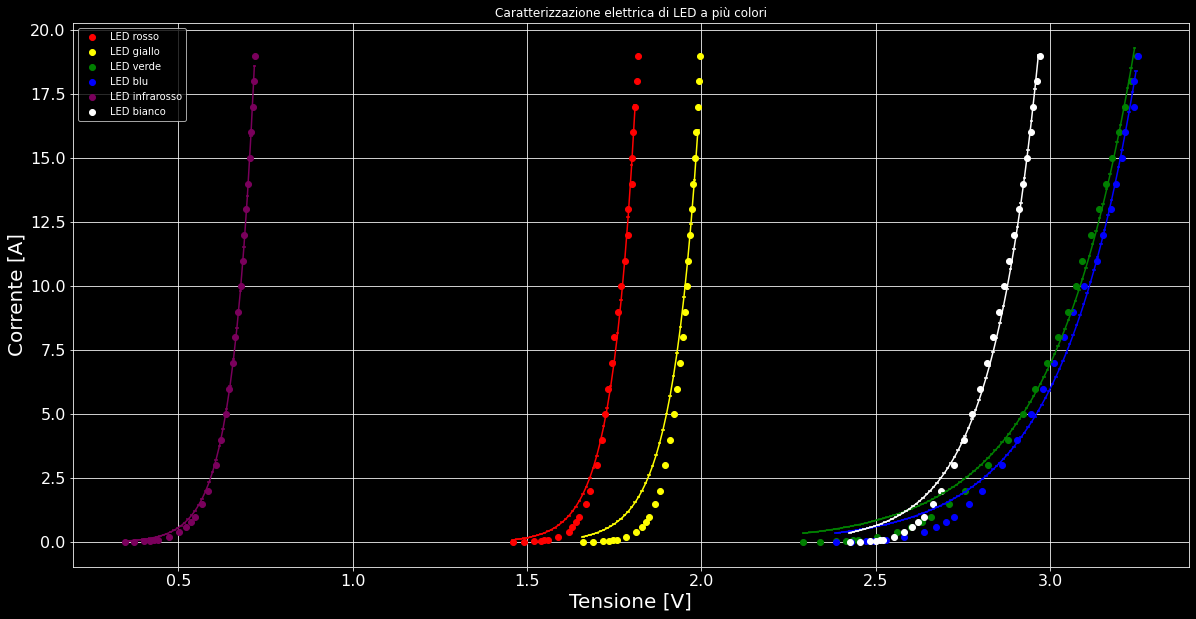

In [ ]:
# Plot dei dati normalizzati

plt.figure(figsize=[20,10])
plt.title('Caratterizzazione elettrica di LED a più colori')
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Tensione [V]', fontsize=20)
plt.ylabel('Corrente [A]', fontsize=20)
plt.plot(rosso,corrente,color='red',marker='o',linestyle='none', label='LED rosso')
plt.plot(giallo,corrente,color='yellow',marker='o',linestyle='none', label='LED giallo')
plt.plot(verde,corrente,color='green',marker='o',linestyle='none', label='LED verde')
plt.plot(blu,corrente,color='blue',marker='o',linestyle='none', label='LED blu')
plt.plot(fotodiodo,corrente,color='#7A005C',marker='o',linestyle='none', label='LED infrarosso')
plt.plot(bianco,corrente,color='white',marker='o',linestyle='none', label='LED bianco')

xmin_rosso,xmax_rosso=rosso[0],rosso[ndata-1]
x_rosso=np.arange(xmin_rosso,xmax_rosso+1e-5,0.01)
y_rosso=rossof(x_rosso,I0_fit_rosso,n_fit_rosso)
plt.errorbar(x_rosso,y_rosso,yerr=0.0005,xerr=0.005,linestyle="",color='red')
plt.plot(x_rosso,y_rosso,color='red')

xmin_giallo,xmax_giallo=giallo[0],giallo[ndata-1]
x_giallo=np.arange(xmin_giallo,xmax_giallo+1e-5,0.01)
y_giallo=giallof(x_giallo,I0_fit_giallo,n_fit_giallo)
plt.errorbar(x_giallo,y_giallo,yerr=0.0005,xerr=0.005,linestyle="",color='yellow')
plt.plot(x_giallo,y_giallo,color='yellow')

xmin_verde,xmax_verde=verde[0],verde[ndata-1]
x_verde=np.arange(xmin_verde,xmax_verde+1e-5,0.01)
y_verde=verdef(x_verde,I0_fit_verde,n_fit_verde)
plt.errorbar(x_verde,y_verde,yerr=0.0005,xerr=0.005,linestyle="",color='green')
plt.plot(x_verde,y_verde,color='green')

xmin_blu,xmax_blu=blu[0],blu[ndata-1]
x_blu=np.arange(xmin_blu,xmax_blu+1e-5,0.01)
y_blu=bluf(x_blu,I0_fit_blu,n_fit_blu)
plt.errorbar(x_blu,y_blu,yerr=0.0005,xerr=0.005,linestyle="",color='blue')
plt.plot(x_blu,y_blu,color='blue')

xmin,xmax=fotodiodo[0],fotodiodo[ndata-1]
x_fotodiodo=np.arange(xmin,xmax+1e-5,0.01)
y_fotodiodo=fotodiodof(x_fotodiodo,I0_fit_fotodiodo,n_fit_fotodiodo)
plt.errorbar(x_fotodiodo,y_fotodiodo,yerr=0.0005,xerr=0.005,linestyle="",color='#7A005C')
plt.plot(x_fotodiodo,y_fotodiodo,color='#7A005C')

xmin,xmax=bianco[0],bianco[ndata-1]
x_bianco=np.arange(xmin,xmax+1e-5,0.01)
y_bianco=biancof(x_bianco,I0_fit_bianco,n_fit_bianco)
plt.errorbar(x_bianco,y_bianco,yerr=0.0005,xerr=0.005,linestyle="",color='white')
plt.plot(x_bianco,y_bianco,color='white')

plt.legend()
plt.style.use("dark_background")

### Caratterizzazione ottica di vari LED

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
import matplotlib.pyplot as plt  
import pandas as pd

# Importa i dati

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/04_LED_ELECTRIC_OPTIC/LED_OPTIC_SPECTRUM.CSV'

data = pd.read_csv(filename)

# Converti i dati in numpy arrays

wavelenght=data['λ (nm)'].to_numpy()
tensione1=data['Red V (mV)'].to_numpy()
tensione1=tensione1/np.max(tensione1)
tensione2=data['Yellow V (mV)'].to_numpy()
tensione2=tensione2/np.max(tensione2)
tensione3=data['Green V (mV)'].to_numpy()
tensione3=tensione3/np.max(tensione3)
tensione4=data['Blue V (mV)'].to_numpy()
tensione4=tensione4/np.max(tensione4)
tensione5=data['IR diode V (mV)'].to_numpy()
tensione5=tensione5/np.max(tensione5)
tensione6=data['White V (mV)'].to_numpy()
tensione6=tensione6/np.max(tensione6)

print('Importazione dei dati completata.')

Importazione dei dati completata.


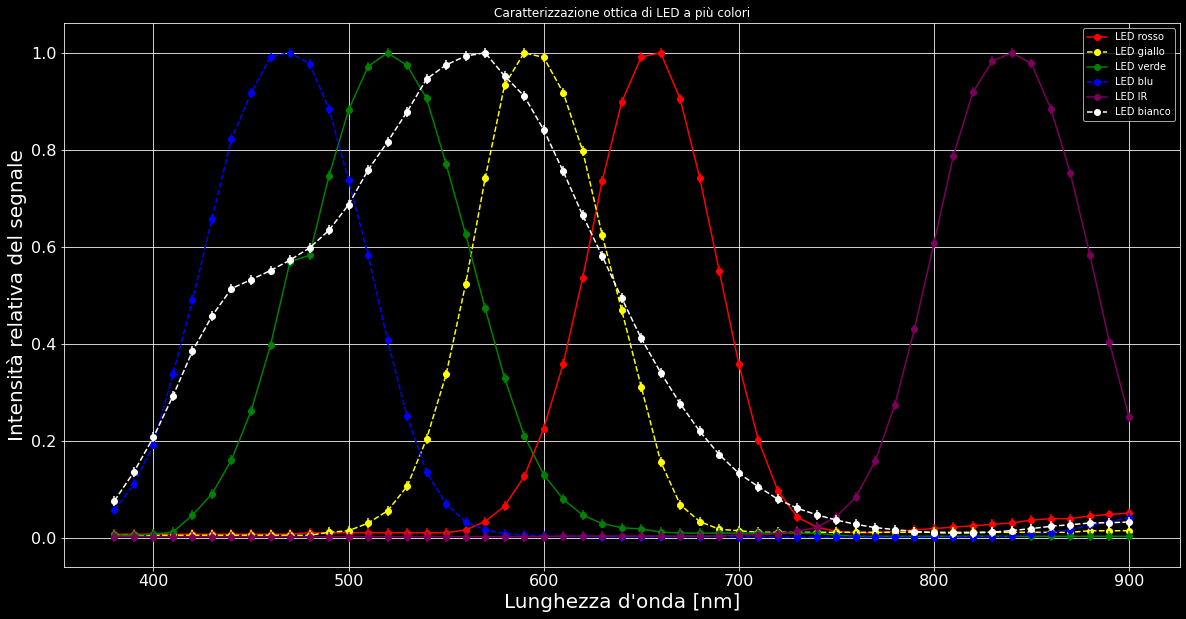

In [ ]:
# Plot dei dati normalizzati

plt.figure(figsize=[20,10])
plt.title('Caratterizzazione ottica di LED a più colori')
plt.xlabel('Lunghezza d\'onda [nm]', fontsize=20)
plt.ylabel('Intensità relativa del segnale', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(wavelenght,tensione1,yerr=0.01,linestyle="",color='red')
plt.plot(wavelenght,tensione1,color='red',marker='o', linestyle='solid', label='LED rosso')
plt.errorbar(wavelenght,tensione2,yerr=0.01,linestyle="",color='yellow')
plt.plot(wavelenght,tensione2,color='yellow',marker='o', linestyle='dashed', label='LED giallo')
plt.errorbar(wavelenght,tensione3,yerr=0.01,linestyle="",color='green')
plt.plot(wavelenght,tensione3,color='green',marker='o', linestyle='solid', label='LED verde')
plt.errorbar(wavelenght,tensione4,yerr=0.01,linestyle="",color='blue')
plt.plot(wavelenght,tensione4,color='blue',marker='o', linestyle='dashed', label='LED blu')
plt.errorbar(wavelenght,tensione5,yerr=0.01,linestyle="",color='#7A005C')
plt.plot(wavelenght,tensione5,color='#7A005C',marker='o', linestyle='solid', label='LED IR')
plt.errorbar(wavelenght,tensione6,yerr=0.01,linestyle="",color='white')
plt.plot(wavelenght,tensione6,color='white',marker='o', linestyle='dashed', label='LED bianco')
plt.style.use("dark_background")
plt.legend()

print('')

## Discussione dei risultati e conclusione

Dai fit della parte sulla caratterizzazione elettrica si ottengono valori di corrente di saturazione inversa piuttosto verosimili, se comparati all'energia crescente della radiazione emessa andando dal rosso al blu. La verifica della legge esponenziale è pressoché perfettamente verificata, salvo per una piccola regione relativa ai LED giallo e bianco.

Nell'esecuzione della caratterizzazione ottica è stato cruciale l’allineamento corretto del braccio portante il fotodiodo e del foglio goniometrico rispetto a questo. In particolare, si è convenuto di cercare prima l’ordine zero, allineare il foglio e posizionarlo in modo che l’estremità dell’asta vada a coincidere con la linea dei 39 cm, verificando che quindi, ruotando l’asta, l’estremità continui a scorrere sempre su tale linea per ogni LED utilizzato.

Confrontando la tensione di inizio accensione, quella corrispondente alla transizione tra regime esponenziale e regime lineare e quella corrispondente ad un valore prefissato di corrente (1 mA), relativa ai dati poc'anzi illustrati e quelli su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/blob/main/04_LED_ELECTRIC_OPTIC/LED_PARAMETERS.CSV) si nota un certo accordo tra i valori della caratterizzazione elettrica e quella ottica.

Per questi motivi si ritiene che gli scopi della prova siano stati raggiunti con successo.